# Department & Division Analysis

This notebook analyzes UCSD CAPEs data sliced by:
- **Department** (e.g. CSE, MATH, ECE)
- **Division** (Lower: 1–99, Upper: 100–199, Grad: 200+)


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
root_dir = next((path for path in [cwd, *cwd.parents] if (path / "src").exists() and (path / "data" / "capes_data.csv").exists()), None)
if root_dir is None:
    raise FileNotFoundError("Could not find the project root from the current notebook working directory.")
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.capes_analysis import clean_capes_analysis_frame, load_capes_data, load_provider_release_frames, provider_frames_to_quarter_events
from src import department_helpers as dh

data_dir = root_dir / 'data' / 'capes_data.csv'

df_raw = load_capes_data(data_dir)
print(f'Loaded {len(df_raw):,} rows')
df_raw.head(3)



Loaded 63,363 rows


,Instructor,Course,Quarter,Total Enrolled in Course,Total CAPEs Given,Percentage Recommended Class,Percentage Recommended Professor,Study Hours per Week,Average Grade Expected,Average Grade Received,Evalulation URL
0,Butler Elizabeth Annette,AAS 10 - Intro/African-American Studies (A),SP23,66,48,93.5%,100.0%,2.80,A- (3.84),B+ (3.67),https://cape.ucsd.edu/CAPEReport.aspx?sectioni...
1,Butler Elizabeth Annette,AAS 170 - Legacies of Research (A),SP23,20,7,100.0%,100.0%,2.50,A- (3.86),A- (3.92),https://cape.ucsd.edu/CAPEReport.aspx?sectioni...
2,Jones Ian William Nasser,ANAR 111 - Foundations of Archaeology (A),SP23,16,3,100.0%,100.0%,3.83,B+ (3.67),NaN,https://cape.ucsd.edu/CAPEReport.aspx?sectioni...


## 2. Data Cleaning & Feature Extraction

In [2]:
df_clean = clean_capes_analysis_frame(df_raw).dropna(subset=['Department'])
print(f'Clean rows (with GPA_Received): {len(df_clean):,}')
print(f'Unique departments: {df_clean["Department"].nunique()}')
print('Division breakdown:')
print(df_clean['Division'].value_counts())


Clean rows (with GPA_Received): 41,179
Unique departments: 126
Division breakdown:
Division
Upper Division (100-199)    27194
Lower Division (1-99)       13985
Name: count, dtype: int64


## 3. Load LLM Release Dates

In [3]:
provider_frames = load_provider_release_frames(root_dir / 'data')
print('GPT columns:', provider_frames['GPT'].columns.tolist())
provider_frames['GPT'].head(3)


GPT columns: ['Time', 'Model']


,Time,Model
0,June 2018,GPT-1
1,February 2019,GPT2
2,June 2020,GPT-3


In [4]:
all_llm_events = provider_frames_to_quarter_events(provider_frames, min_year=2020, max_year=2024)
llm_colors = {'GPT': 'green', 'Claude': 'purple', 'Gemini': 'blue', 'Grok': 'orange'}

print(f'LLM events in range: {len(all_llm_events)}')
for t, model, brand in all_llm_events:
    print(f'  {t:.2f}  [{brand}] {model}')


LLM events in range: 8
  2020.50  [GPT] GPT-3
  2022.92  [GPT] GPT-3.5
  2023.25  [GPT] GPT-4
  2023.25  [Claude] Claude 1
  2023.58  [Claude] Claude 2
  2023.92  [Claude] Claude 2.1
  2023.92  [Grok] Grok-1
  2024.00  [Gemini] Gemini 1.0


## 4. Department Analysis

### 4.1 Top 15 Departments by Record Count

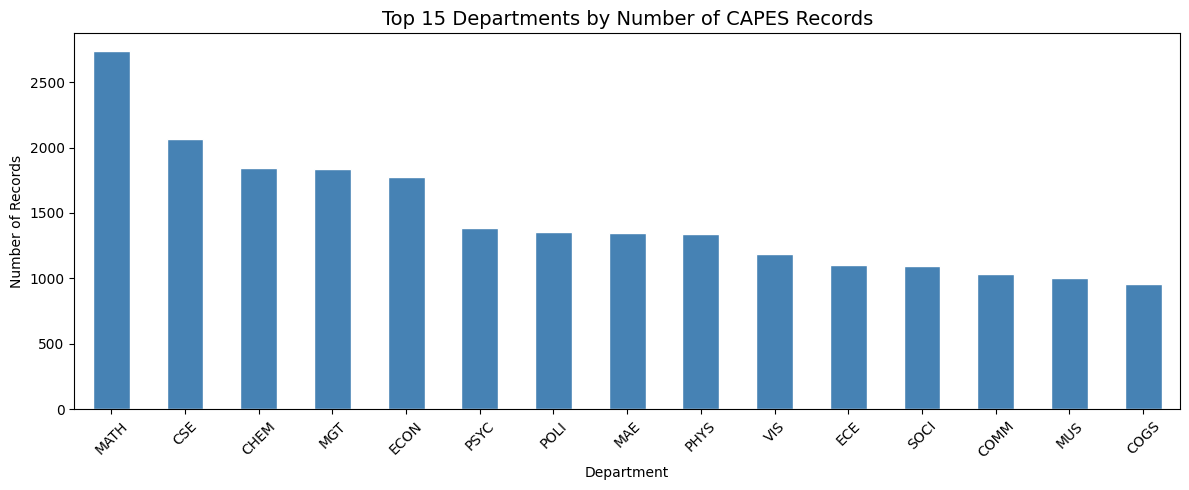

Top 15 departments: ['MATH', 'CSE', 'CHEM', 'MGT', 'ECON', 'PSYC', 'POLI', 'MAE', 'PHYS', 'VIS', 'ECE', 'SOCI', 'COMM', 'MUS', 'COGS']


In [5]:
top15_depts, TOP_DEPTS = dh.top_department_counts(df_clean)
dh.plot_department_record_counts(top15_depts, 'figures/dept_record_count.png')
print('Top 15 departments:', TOP_DEPTS)


### 4.2 Average GPA Received by Department (Top 15)

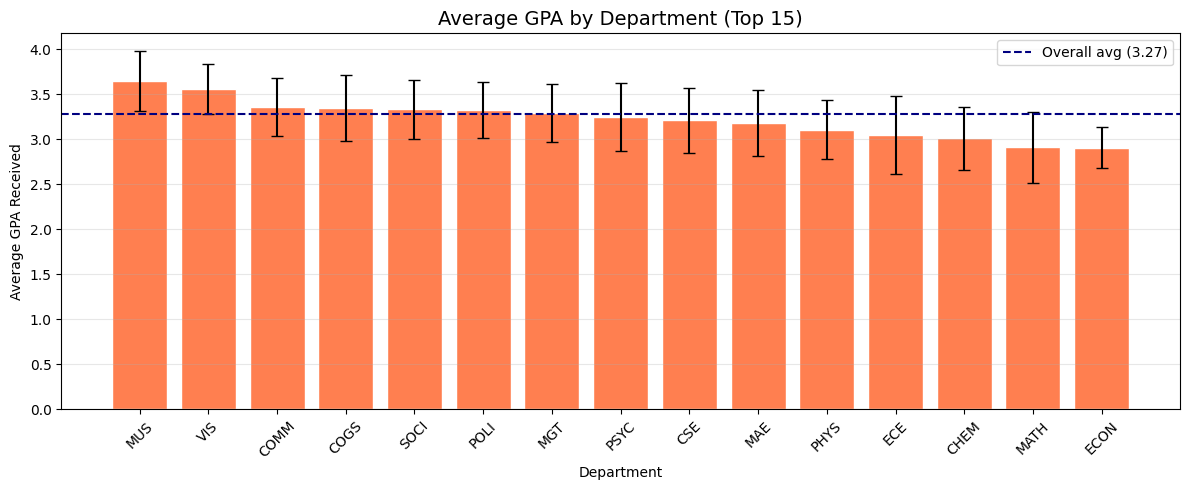

,mean,std,count
Department,,,
MUS,3.646,0.331,1004
VIS,3.559,0.277,1189
COMM,3.360,0.324,1032
COGS,3.346,0.366,956
SOCI,3.335,0.327,1095
POLI,3.321,0.309,1353
MGT,3.288,0.322,1833
PSYC,3.249,0.380,1384
CSE,3.212,0.360,2063


In [6]:
dept_gpa = dh.summarize_department_gpa(df_clean, TOP_DEPTS)
dh.plot_department_gpa_summary(
    dept_gpa,
    overall_mean=df_clean['GPA_Received'].mean(),
    save_path='figures/dept_avg_gpa.png',
)
dept_gpa.round(3)


### 4.3 GPA Trend Over Time — Focus Departments (CSE, MATH, ECE, ECON)

Plotting departments: ['CSE', 'MATH', 'ECE', 'ECON']


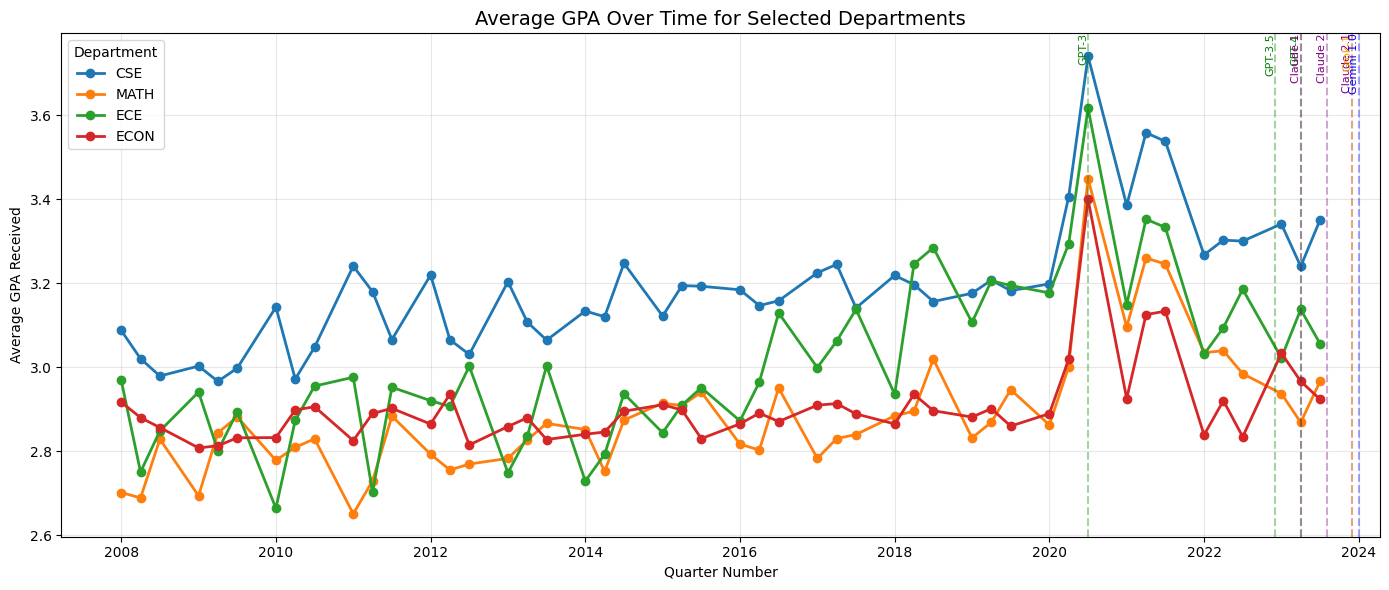

,Quarter_Num,Department,GPA_Received
0,2008.00,CSE,3.087143
1,2008.00,ECE,2.968333
2,2008.00,ECON,2.916591
3,2008.00,MATH,2.701163
4,2008.25,CSE,3.020000


In [7]:
FOCUS_DEPTS = dh.focus_departments(df_clean)
print('Plotting departments:', FOCUS_DEPTS)

trend = dh.build_department_trend(df_clean, FOCUS_DEPTS)
dh.plot_department_trend(
    trend,
    FOCUS_DEPTS,
    all_llm_events,
    llm_colors,
    'figures/dept_gpa_trend_llm.png',
)
trend.head()


### 4.4 Recommendation Rate by Department

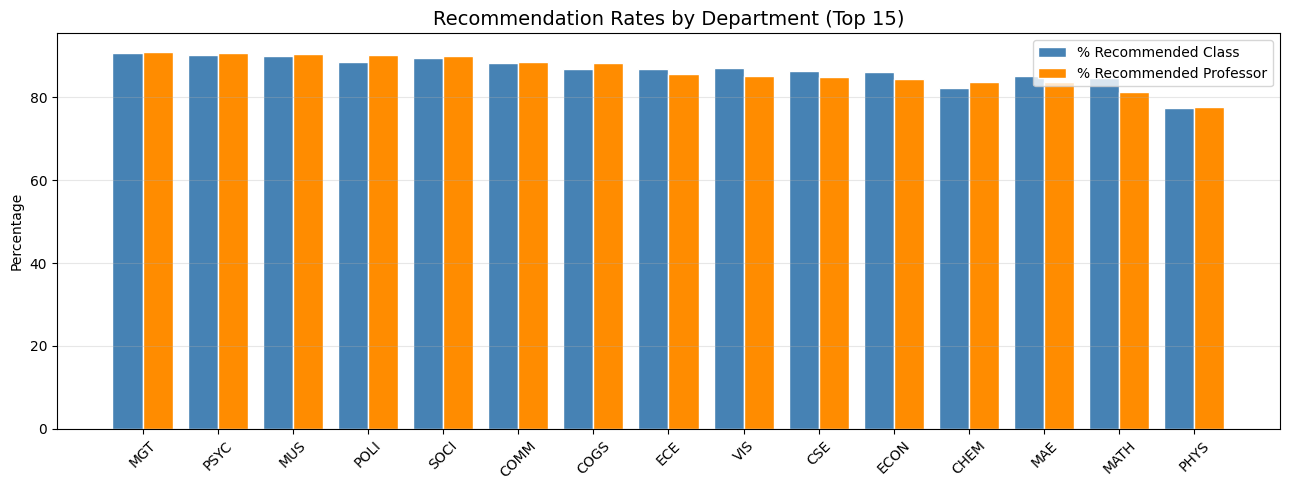

,Pct_Rec_Class,Pct_Rec_Prof
Department,,
MGT,90.81,90.92
PSYC,90.27,90.74
MUS,90.02,90.53
POLI,88.49,90.17
SOCI,89.44,90.07
COMM,88.32,88.54
COGS,86.88,88.27
ECE,86.89,85.69
VIS,87.16,85.15


In [8]:
dept_rec = dh.summarize_department_recommendations(df_clean, TOP_DEPTS)
dh.plot_department_recommendations(dept_rec, 'figures/dept_rec_rate.png')
dept_rec.round(2)


## 5. Division Analysis (Lower vs Upper vs Graduate)

### 5.1 GPA Distribution by Division

/Users/jeevan/Library/Mobile Documents/com~apple~CloudDocs/College docs/Courses/ECE 143/ECE143_LLM_Impact/src/department_helpers.py:202: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


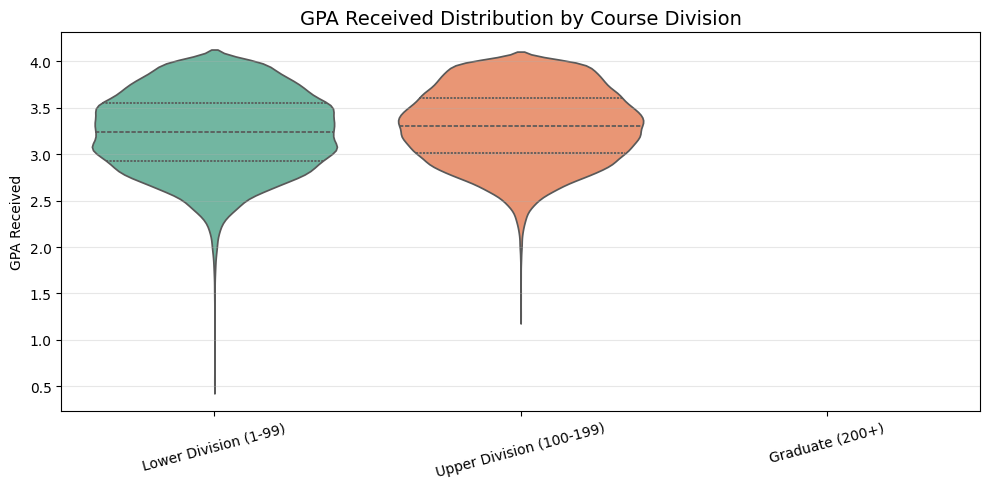

In [9]:
div_order = dh.DIVISION_ORDER.copy()
df_div, div_order = dh.filter_division_frame(df_clean, div_order)
dh.plot_division_gpa_distribution(df_div, div_order, 'figures/division_gpa_violin.png')


### 5.2 Study Hours by Division

/Users/jeevan/Library/Mobile Documents/com~apple~CloudDocs/College docs/Courses/ECE 143/ECE143_LLM_Impact/src/department_helpers.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


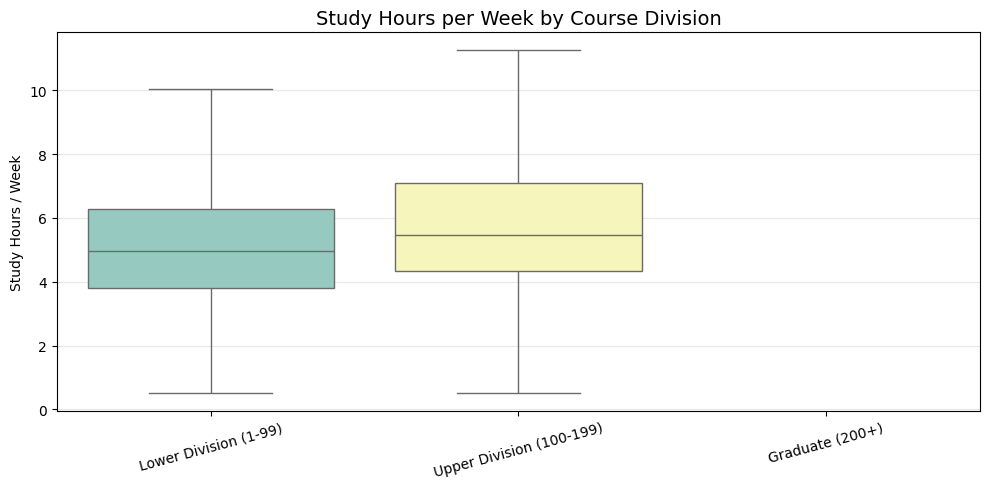

In [10]:
df_div_hours = dh.filter_division_hours(df_div)
dh.plot_division_study_hours(df_div_hours, div_order, 'figures/division_study_hours.png')


### 5.3 GPA Trend Over Time by Division (with LLM Markers)

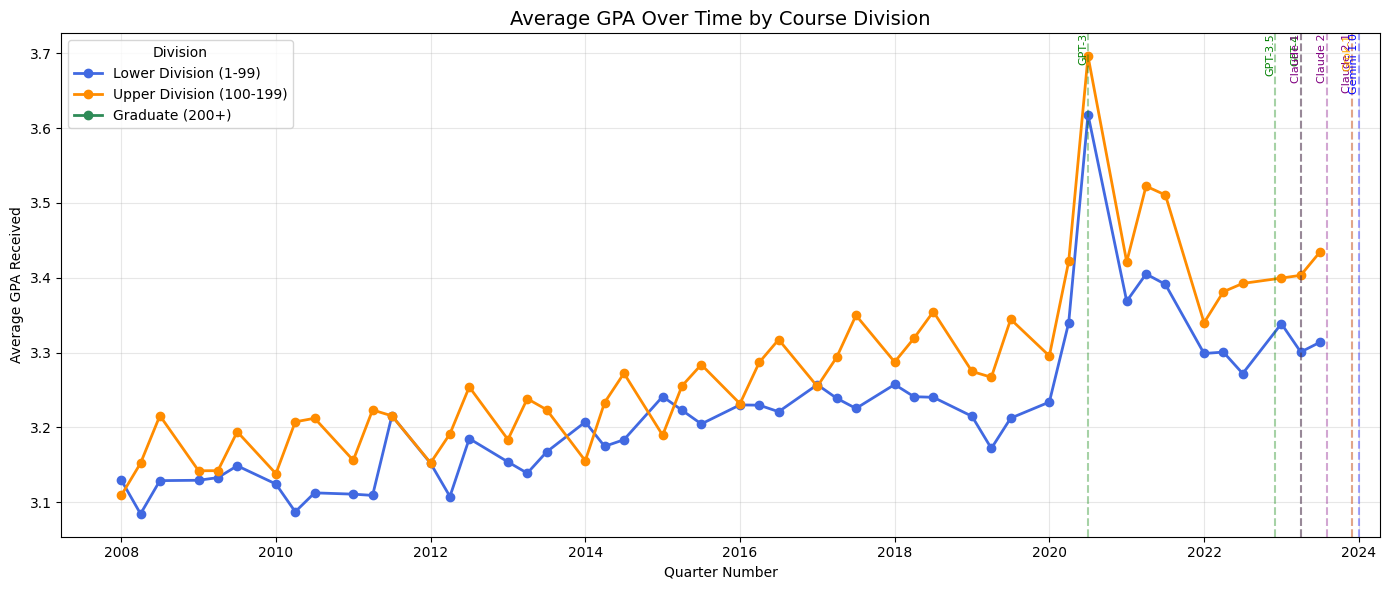

,Quarter_Num,Division,GPA_Received
0,2008.00,Lower Division (1-99),3.129740
1,2008.00,Upper Division (100-199),3.109082
2,2008.25,Lower Division (1-99),3.084526
3,2008.25,Upper Division (100-199),3.152192
4,2008.50,Lower Division (1-99),3.128889


In [11]:
div_trend = dh.build_division_trend(df_div)
dh.plot_division_trend(
    div_trend,
    div_order,
    all_llm_events,
    llm_colors,
    'figures/division_gpa_trend_llm.png',
)
div_trend.head()


### 5.4 GPA by Division — Focus Departments

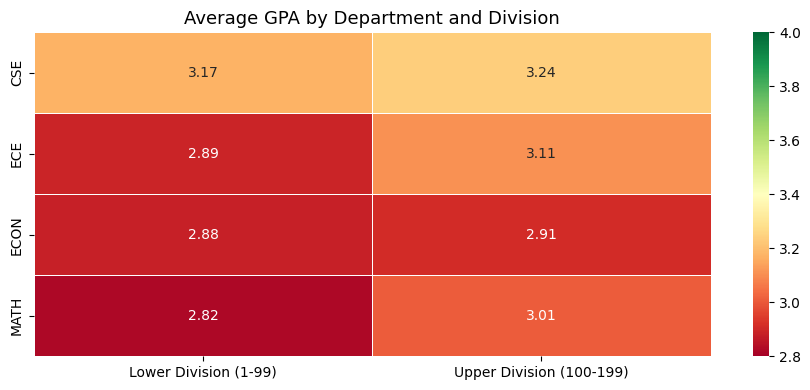

Division,Lower Division (1-99),Upper Division (100-199)
Department,,
CSE,3.174,3.238
ECE,2.891,3.108
ECON,2.884,2.909
MATH,2.819,3.011


In [12]:
pivot = dh.build_department_division_heatmap(df_clean, FOCUS_DEPTS, div_order)
dh.plot_department_division_heatmap(pivot, 'figures/dept_division_gpa_heatmap.png')
pivot.round(3)


## 6. Pre- vs Post-LLM Comparison

Split at **Nov 2022** (ChatGPT / GPT-3.5 release — first widely accessible LLM).

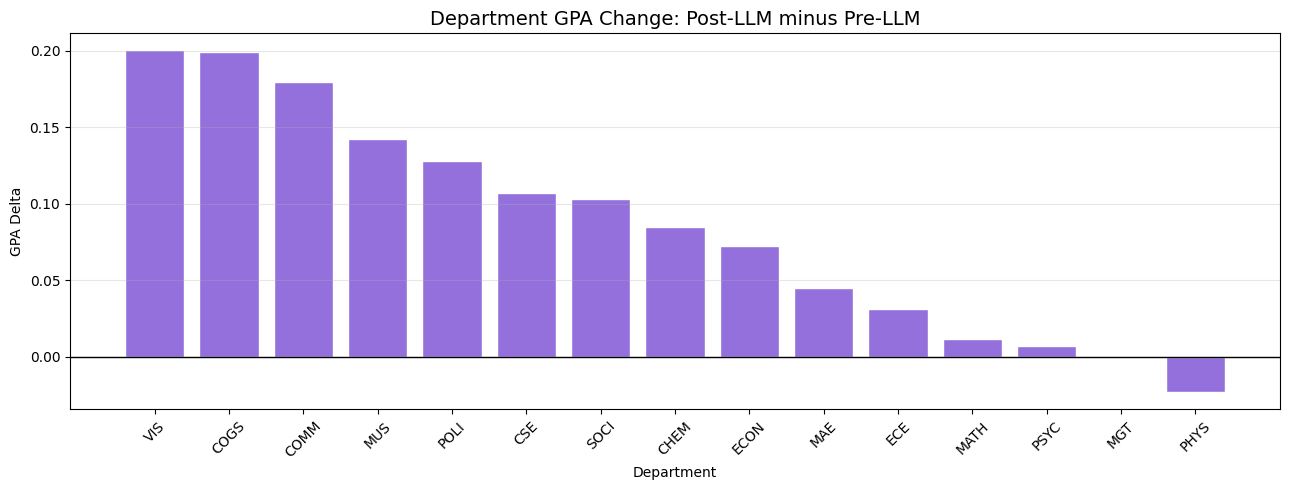

Era,Post-LLM (after Nov 2022),Pre-LLM,Delta
Department,,,
VIS,3.745,3.545,0.200
COGS,3.529,3.329,0.199
COMM,3.527,3.347,0.180
MUS,3.779,3.636,0.142
POLI,3.442,3.315,0.128
CSE,3.313,3.206,0.107
SOCI,3.430,3.327,0.103
CHEM,3.088,3.003,0.085
ECON,2.973,2.901,0.073


In [13]:
df_clean = dh.add_era_column(df_clean)
era_dept = dh.summarize_department_era_delta(df_clean, TOP_DEPTS)
dh.plot_department_era_delta(era_dept, 'figures/dept_pre_post_llm_delta.png')
era_dept.round(3)


## 7. Summary Statistics

In [14]:
dh.print_department_summary(df_clean, div_order)


=== Overall GPA Statistics ===
count    41179.000
mean         3.274
std          0.404
min          0.550
25%          2.980
50%          3.290
75%          3.590
max          4.000
Name: GPA_Received, dtype: float64

=== GPA by Division ===
                           mean  median    std  count
Division                                             
Lower Division (1-99)     3.232    3.24  0.420  13985
Upper Division (100-199)  3.296    3.30  0.394  27194

=== Pre vs Post LLM (all departments) ===
                            mean  count
Era                                    
Post-LLM (after Nov 2022)  3.379   3132
Pre-LLM                    3.266  38047
